# LLM-Powered Intelligent Job Matching System

**Name**: PAINDA MOHAMMAD FAYAZ
**Student ID**: 22511204
**Date**: 2026-06
**Topic**: Job Matching

---

## 1. Problem Background

Recruiting teams face two scaling problems:

| Pain Point | Description |
|---|---|
| Low efficiency | HR spends 5-10 minutes manually comparing each resume to job requirements |
| Subjective scoring | Different recruiters use different criteria, hard to quantify |
| Black-box rejections | Candidates rarely learn *why* they were a poor fit |
| Multi-dimensional tradeoffs | Skills, experience, education, location, salary all matter — and the weights differ per role |

## 2. Solution

This project combines **rule-based scoring** with a **Large Language Model (LLM)**:

1. **Data input** — load job and candidate databases (CSV), supporting interactive selection
2. **Quantitative analysis** — compute a composite score from skills overlap, experience match, education match, location match
3. **Results display** — sortable table + dual bar charts (total + per-dimension)
4. **Parameter interaction** — adjust dimension weights, filter by location/salary, control the number of recommendations
5. **LLM enhancement** — call Claude to generate a natural-language explanation and advice for the top recommendation

> **Why this design?**
> Pure rules are **transparent but rigid**; pure LLM is **flexible but opaque and expensive**.
> Combined: rules provide an auditable quantitative base, LLM adds semantic understanding and human-readable advice.


## 3. Setup

Load dependencies, configure plotting, and initialize the Claude API client.


In [1]:
# Standard library
import os
import warnings
warnings.filterwarnings("ignore")

# Data & ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Jupyter interactivity
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown, HTML

# LLM (Anthropic Claude)
from dotenv import load_dotenv
from anthropic import Anthropic

# Load environment variables
load_dotenv()
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
LLM_MODEL = os.getenv("LLM_MODEL", "claude-opus-4-7")

client = None
if ANTHROPIC_API_KEY and not ANTHROPIC_API_KEY.startswith("sk-ant-your-"):
    client = Anthropic(api_key=ANTHROPIC_API_KEY)
    print(f"Claude API ready: model={LLM_MODEL}")
else:
    print("No ANTHROPIC_API_KEY detected — LLM features will use mock responses.")
    print("Copy .env.example to .env and add your API key to enable real LLM calls.")


No ANTHROPIC_API_KEY detected — LLM features will use mock responses.
Copy .env.example to .env and add your API key to enable real LLM calls.


---

## Module 1: Data Input

Load the job database (`jobs.csv`) and candidate database (`candidates.csv`).
**~80 jobs + ~25 candidates**, covering:
- **Backend**: Python / Java / Go / Node.js / Ruby / C++
- **Frontend**: React / Vue / Full Stack
- **Mobile**: iOS / Android / Flutter / React Native
- **Data & AI**: Data Analysis / Data Science / ML / NLP / CV / Recommendation / LLM
- **QA & DevOps**: Test Automation / DevOps / SRE / Cloud
- **Product & Design**: PM / UI / UX / Visual
- **Other**: Security / Blockchain / Embedded / FPGA

Companies span big tech (Google, Microsoft, Meta), AI labs (OpenAI, Anthropic, Mistral), unicorns (Stripe, Databricks), midsize (GitHub, Cloudflare), and startups. Locations across major US tech hubs + remote.


In [2]:
# Load datasets
jobs_df = pd.read_csv("data/jobs.csv")
candidates_df = pd.read_csv("data/candidates.csv")

print(f"Loaded: {len(jobs_df)} jobs / {len(candidates_df)} candidates\n")
print("=== Jobs preview (top 10) ===")
display(jobs_df.head(10))
print("\n=== Candidates preview (top 10) ===")
display(candidates_df.head(10))

# Quick stats
print("\n=== Data distribution ===")
print(f"Jobs by location: {dict(jobs_df['location'].value_counts())}")
print(f"Jobs by education requirement: {dict(jobs_df['education'].value_counts())}")
print(f"Candidates by education: {dict(candidates_df['education'].value_counts())}")
print(f"Salary range: ${jobs_df['salary_min'].min():,} - ${jobs_df['salary_max'].max():,}")


Loaded: 77 jobs / 26 candidates

=== Jobs preview (top 10) ===


,job_id,title,company,location,required_skills,min_experience,education,salary_min,salary_max,description
0,J001,Senior Python Backend Engineer,Meta,"Austin, TX","Python,Django,FastAPI,PostgreSQL,Redis,Docker,...",4,Bachelor,182000,260000,"Build and maintain scalable backend services, ..."
1,J002,Java Backend Engineer,Google,Remote,"Java,Spring,SpringBoot,MySQL,Kafka,Redis",4,Bachelor,169000,247000,"Develop core business systems, participate in ..."
2,J003,Java Backend Engineer,Amazon,"San Francisco, CA","Java,Spring,SpringBoot,MySQL,Kafka,Redis",4,Bachelor,169000,247000,"Develop core business systems, participate in ..."
3,J004,Junior Java Developer,Microsoft,Remote,"Java,Spring,SQL,Git",1,Bachelor,104000,156000,"Build features under mentorship, write unit te..."
4,J005,Go Backend Engineer,Vercel,Remote,"Go,gRPC,PostgreSQL,Redis,Kubernetes",3,Bachelor,180000,252000,"Build microservices in Go, handle high-concurr..."
5,J006,Node.js Backend Engineer,Apple,"Boston, MA","Node.js,Express,TypeScript,MongoDB,Redis",3,Bachelor,156000,234000,"Build backend-for-frontend services, REST + Gr..."
6,J007,Node.js Backend Engineer,GitHub,"Seattle, WA","Node.js,Express,TypeScript,MongoDB,Redis",3,Bachelor,120000,180000,"Build backend-for-frontend services, REST + Gr..."
7,J008,Node.js Backend Engineer,Snowflake,"Boston, MA","Node.js,Express,TypeScript,MongoDB,Redis",3,Bachelor,144000,216000,"Build backend-for-frontend services, REST + Gr..."
8,J009,Ruby on Rails Engineer,Adobe,"Los Angeles, CA","Ruby,Rails,PostgreSQL,Sidekiq,Redis",4,Bachelor,169000,247000,"Develop and maintain Rails monolith, write cle..."
9,J010,Ruby on Rails Engineer,Amazon,"New York, NY","Ruby,Rails,PostgreSQL,Sidekiq,Redis",4,Bachelor,169000,247000,"Develop and maintain Rails monolith, write cle..."



=== Candidates preview (top 10) ===


,candidate_id,name,skills,experience_years,education,preferred_location,expected_salary,self_intro
0,C001,Alex Johnson,"Python,Django,FastAPI,PostgreSQL,Redis,Docker,...",5,Bachelor,"San Francisco, CA",180000,"5 years of Python backend experience, led re-a..."
1,C002,Sarah Chen,"Java,Spring,SpringBoot,MySQL,Kafka,Redis",6,Bachelor,"New York, NY",200000,"6 years of Java backend, former tech lead at a..."
2,C003,Michael Brown,"Java,Spring,MySQL,Git,Maven",1,Bachelor,"Austin, TX",95000,"1 year of Java development, looking to join a ..."
3,C004,Emily Davis,"Go,gRPC,PostgreSQL,Kubernetes,Docker",4,Bachelor,"Seattle, WA",195000,"4 years of Go backend, cloud-native specialist..."
4,C005,David Wilson,"Node.js,Express,TypeScript,MongoDB,React",3,Bachelor,"Boston, MA",150000,"3 years of full-stack Node.js, strong BFF desi..."
5,C006,Jessica Martinez,"Ruby,Rails,PostgreSQL,Redis,Sidekiq",5,Bachelor,Remote,165000,"5 years of Rails development, shipped multiple..."
6,C007,James Anderson,"C++,STL,Linux,Multithreading,Networking",4,Bachelor,"Los Angeles, CA",200000,"4 years of C++ game server development, expert..."
7,C008,Olivia Taylor,"JavaScript,React,TypeScript,Redux,Webpack,Next.js",5,Bachelor,"New York, NY",190000,"5 years of frontend experience, React ecosyste..."
8,C009,Daniel Garcia,"JavaScript,Vue,Vuex,HTML,CSS,Webpack",3,Bachelor,"Denver, CO",130000,"3 years of Vue.js development, built multiple ..."
9,C010,Sophia Robinson,"JavaScript,React,TypeScript,HTML,CSS,Hooks,Nex...",4,Bachelor,"San Francisco, CA",170000,"4 years of React development, focused on UX an..."



=== Data distribution ===
Jobs by location: {'Boston, MA': np.int64(12), 'Remote': np.int64(10), 'New York, NY': np.int64(10), 'Chicago, IL': np.int64(8), 'Denver, CO': np.int64(7), 'Austin, TX': np.int64(6), 'San Francisco, CA': np.int64(6), 'Seattle, WA': np.int64(6), 'Los Angeles, CA': np.int64(6), 'London, UK': np.int64(6)}
Jobs by education requirement: {'Bachelor': np.int64(65), 'Master': np.int64(10), 'Associate': np.int64(2)}
Candidates by education: {'Bachelor': np.int64(20), 'Master': np.int64(5), 'Associate': np.int64(1)}
Salary range: $60,000 - $416,000


---

## Module 2: Analysis & Decision

### 2.1 Rule-Based Scoring

Each *candidate × job* pair is scored on four dimensions (each 0-1):

| Dimension | Formula |
|---|---|
| **Skills match** | `|candidate_skills ∩ job_required_skills| / |job_required_skills|` |
| **Experience match** | 1.0 if candidate_exp ≥ job_min_exp; else proportional |
| **Education match** | Mapped levels (Associate=1, Bachelor=2, Master=3, PhD=4); 1.0 if meets/exceeds |
| **Location match** | 1.0 for exact match, 0.3 otherwise (preserves remote/relocation options) |


In [3]:
EDUCATION_LEVELS = {"Associate": 1, "Bachelor": 2, "Master": 3, "PhD": 4}

def parse_skills(skills_str):
    """Split a comma-separated skill string into a normalized set."""
    return {s.strip().lower() for s in str(skills_str).split(",") if s.strip()}

def skill_match_score(cand_skills, job_skills):
    cand_set = parse_skills(cand_skills)
    job_set = parse_skills(job_skills)
    if not job_set:
        return 0.0
    return len(cand_set & job_set) / len(job_set)

def experience_match_score(cand_exp, job_exp):
    if cand_exp >= job_exp:
        return 1.0
    return cand_exp / max(job_exp, 1)

def education_match_score(cand_edu, job_edu):
    c = EDUCATION_LEVELS.get(cand_edu, 0)
    j = EDUCATION_LEVELS.get(job_edu, 0)
    if c >= j:
        return 1.0
    return c / max(j, 1)

def location_match_score(cand_loc, job_loc):
    if cand_loc == job_loc:
        return 1.0
    if "Remote" in (cand_loc, job_loc):
        return 0.7
    return 0.3

def calculate_match(candidate, job, weights):
    """Calculate the overall match score given weights."""
    s_score = skill_match_score(candidate["skills"], job["required_skills"])
    e_score = experience_match_score(candidate["experience_years"], job["min_experience"])
    ed_score = education_match_score(candidate["education"], job["education"])
    l_score = location_match_score(candidate["preferred_location"], job["location"])
    total = (
        weights["skills"] * s_score
        + weights["experience"] * e_score
        + weights["education"] * ed_score
        + weights["location"] * l_score
    )
    return {
        "total": round(total * 100, 1),
        "skill": round(s_score * 100, 1),
        "experience": round(e_score * 100, 1),
        "education": round(ed_score * 100, 1),
        "location": round(l_score * 100, 1),
    }

def match_all_jobs(candidate, jobs, weights):
    rows = []
    for _, job in jobs.iterrows():
        s = calculate_match(candidate, job, weights)
        rows.append({
            "job_id": job["job_id"],
            "title": job["title"],
            "company": job["company"],
            "location": job["location"],
            "salary": f"${job['salary_min']:,}-${job['salary_max']:,}",
            "total_score": s["total"],
            "skill_score": s["skill"],
            "exp_score": s["experience"],
            "edu_score": s["education"],
            "loc_score": s["location"],
        })
    return pd.DataFrame(rows).sort_values("total_score", ascending=False).reset_index(drop=True)

# Quick sanity check
demo_weights = {"skills": 0.5, "experience": 0.2, "education": 0.15, "location": 0.15}
demo_cand = candidates_df.iloc[0]
demo_result = match_all_jobs(demo_cand, jobs_df, demo_weights)
print(f"Test: Top 3 matches for {demo_cand['name']}:")
display(demo_result.head(3))


Test: Top 3 matches for Alex Johnson:


,job_id,title,company,location,salary,total_score,skill_score,exp_score,edu_score,loc_score
0,J001,Senior Python Backend Engineer,Meta,"Austin, TX","$182,000-$260,000",89.5,100.0,100.0,100.0,30.0
1,J053,Site Reliability Engineer,Netflix,"San Francisco, CA","$221,000-$325,000",66.7,33.3,100.0,100.0,100.0
2,J005,Go Backend Engineer,Vercel,Remote,"$180,000-$252,000",65.5,40.0,100.0,100.0,70.0


### 2.2 LLM-Enhanced Analysis

Call Claude to generate, for a single *candidate × job* pair:
- Match highlights (where the candidate fits)
- Main gaps (where they fall short)
- One-line recommendation

This is the semantic-level understanding that pure rules can't provide.


In [4]:
def llm_explain_match(candidate, job, scores):
    """Call Claude to produce a natural-language explanation of the match."""
    if client is None:
        return f"""**[Mock Response]**
Candidate **{candidate['name']}** matches **{job['title']} @ {job['company']}** at **{scores['total']}/100**.
- Skills: {scores['skill']}/100
- Experience: {scores['experience']}/100
- Education: {scores['education']}/100
- Location: {scores['location']}/100

*Set `ANTHROPIC_API_KEY` in `.env` to enable real Claude analysis.*"""

    prompt = f"""You are an experienced HR consultant. Based on the information below, give a concise job match analysis (under 300 words, in Markdown).

[Candidate] {candidate['name']}
- Skills: {candidate['skills']}
- Years of experience: {candidate['experience_years']}
- Education: {candidate['education']}
- Preferred location: {candidate['preferred_location']}
- Expected salary: ${candidate['expected_salary']:,}
- Self-introduction: {candidate['self_intro']}

[Job] {job['title']} @ {job['company']} ({job['location']})
- Required skills: {job['required_skills']}
- Minimum experience: {job['min_experience']} years
- Education requirement: {job['education']}
- Salary range: ${job['salary_min']:,}-${job['salary_max']:,}
- Description: {job['description']}

[System scores] Total {scores['total']}/100 (Skills {scores['skill']}, Experience {scores['experience']}, Education {scores['education']}, Location {scores['location']})

Output format:
### Match Highlights
(2-3 bullets on where the candidate fits well)

### Main Gaps
(2-3 bullets on weaknesses or risks)

### Recommendation
(One-sentence action recommendation for the HR team or the candidate)
"""
    try:
        resp = client.messages.create(
            model=LLM_MODEL,
            max_tokens=600,
            system="You are an experienced and concise HR consultant.",
            messages=[{"role": "user", "content": prompt}],
        )
        return next((b.text for b in resp.content if b.type == "text"), "")
    except Exception as e:
        return f"Claude API call failed: `{e}`"


---

## Module 3: Results Display

Two views side by side:
- **Left**: top-N jobs by total score (horizontal bar chart, colored by score)
- **Right**: per-dimension breakdown for each top job


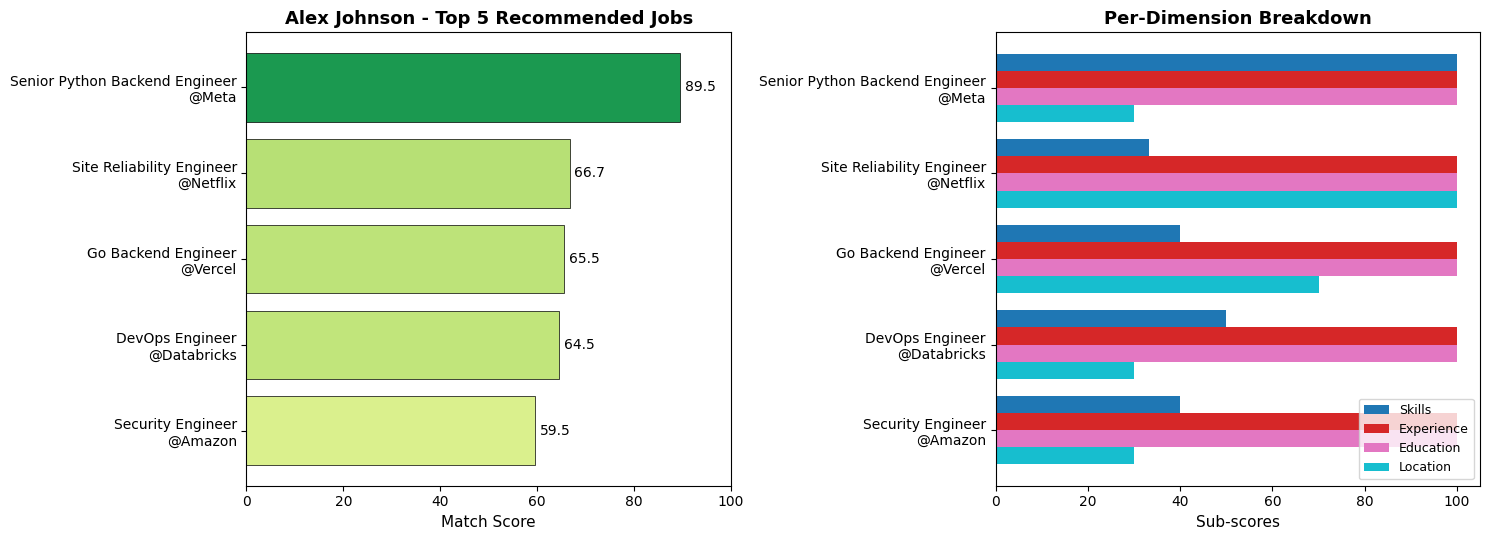

In [5]:
def plot_top_matches(results_df, candidate_name, top_n=5):
    """Visualize the top-N matched jobs."""
    top = results_df.head(top_n).copy()
    labels = [f"{r.title}\n@{r.company}" for r in top.itertuples()]

    fig, axes = plt.subplots(1, 2, figsize=(15, 0.7 * top_n + 2))

    # Total score
    colors = plt.cm.RdYlGn(top["total_score"] / 100)
    axes[0].barh(labels, top["total_score"], color=colors, edgecolor="black", linewidth=0.5)
    axes[0].set_xlabel("Match Score", fontsize=11)
    axes[0].set_title(f"{candidate_name} - Top {top_n} Recommended Jobs", fontsize=13, fontweight="bold")
    axes[0].set_xlim(0, 100)
    axes[0].invert_yaxis()
    for i, v in enumerate(top["total_score"]):
        axes[0].text(v + 1, i, f"{v}", va="center", fontsize=10)

    # Sub-scores
    breakdown = top[["skill_score", "exp_score", "edu_score", "loc_score"]].copy()
    breakdown.columns = ["Skills", "Experience", "Education", "Location"]
    breakdown.index = labels
    breakdown.plot.barh(ax=axes[1], colormap="tab10", width=0.8)
    axes[1].set_xlabel("Sub-scores", fontsize=11)
    axes[1].set_title("Per-Dimension Breakdown", fontsize=13, fontweight="bold")
    axes[1].set_xlim(0, 105)
    axes[1].invert_yaxis()
    axes[1].legend(loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()

# Demo run
plot_top_matches(demo_result, demo_cand["name"], top_n=5)


---

## Module 4: Parameter Interaction

`ipywidgets`-powered interactive panel:

- **Candidate selector**
- **Four weight sliders** (skills / experience / education / location — auto-normalized)
- **Location filter** (multi-select)
- **Minimum salary filter**
- **Top-N control**
- **LLM analysis toggle** (for top 1 job)

Click **Match** to recompute and visualize.


In [6]:
def build_ui():
    """Build the interactive UI."""
    candidate_dropdown = widgets.Dropdown(
        options=[(f"{c['name']} | {c['education']} | {c['experience_years']}y | {c['preferred_location']}", c["candidate_id"]) for _, c in candidates_df.iterrows()],
        description="Candidate:",
        layout=widgets.Layout(width="600px"),
        style={"description_width": "80px"},
    )

    w_skill = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.05, description="Skills:", style={"description_width": "100px"})
    w_exp = widgets.FloatSlider(value=0.2, min=0, max=1, step=0.05, description="Experience:", style={"description_width": "100px"})
    w_edu = widgets.FloatSlider(value=0.15, min=0, max=1, step=0.05, description="Education:", style={"description_width": "100px"})
    w_loc = widgets.FloatSlider(value=0.15, min=0, max=1, step=0.05, description="Location:", style={"description_width": "100px"})

    location_filter = widgets.SelectMultiple(
        options=["Any"] + sorted(jobs_df["location"].unique().tolist()),
        value=["Any"],
        description="Locations:",
        layout=widgets.Layout(width="320px", height="120px"),
        style={"description_width": "80px"},
    )

    salary_min = widgets.IntSlider(value=0, min=0, max=300000, step=10000, description="Min Salary:", style={"description_width": "80px"})
    top_n = widgets.IntSlider(value=5, min=3, max=15, description="Top N:", style={"description_width": "80px"})
    use_llm = widgets.Checkbox(value=True, description="Run Claude analysis on Top 1")

    run_btn = widgets.Button(description="Match", button_style="primary", icon="search", layout=widgets.Layout(width="200px"))
    output = widgets.Output()

    def on_click(_):
        with output:
            clear_output(wait=True)
            cand_id = candidate_dropdown.value
            candidate = candidates_df[candidates_df["candidate_id"] == cand_id].iloc[0]

            # Normalize weights
            total_w = w_skill.value + w_exp.value + w_edu.value + w_loc.value
            if total_w == 0:
                print("All weights are zero — set at least one dimension.")
                return
            weights = {
                "skills": w_skill.value / total_w,
                "experience": w_exp.value / total_w,
                "education": w_edu.value / total_w,
                "location": w_loc.value / total_w,
            }

            # Apply filters
            filtered = jobs_df.copy()
            if "Any" not in location_filter.value:
                filtered = filtered[filtered["location"].isin(location_filter.value)]
            filtered = filtered[filtered["salary_max"] >= salary_min.value]
            if len(filtered) == 0:
                print("No jobs match the current filters — try relaxing them.")
                return

            results = match_all_jobs(candidate, filtered, weights)

            print(f"Candidate: {candidate['name']} | {candidate['education']} | {candidate['experience_years']} years")
            print(f"Normalized weights: Skills {weights['skills']:.0%} | Experience {weights['experience']:.0%} | Education {weights['education']:.0%} | Location {weights['location']:.0%}")
            print(f"Jobs after filter: {len(filtered)} / {len(jobs_df)}\n")

            show_n = min(top_n.value, len(results))
            styled = (
                results.head(show_n)
                .style.background_gradient(subset=["total_score"], cmap="Greens")
                .background_gradient(subset=["skill_score"], cmap="Blues")
                .format({"total_score": "{:.1f}", "skill_score": "{:.1f}", "exp_score": "{:.1f}", "edu_score": "{:.1f}", "loc_score": "{:.1f}"})
            )
            display(styled)

            plot_top_matches(results, candidate["name"], top_n=show_n)

            if use_llm.value and len(results) > 0:
                print("\n" + "=" * 60)
                print("Claude Analysis (Top 1 Recommendation)")
                print("=" * 60)
                top_row = results.iloc[0]
                top_job = jobs_df[jobs_df["job_id"] == top_row["job_id"]].iloc[0]
                top_scores = {
                    "total": top_row["total_score"],
                    "skill": top_row["skill_score"],
                    "experience": top_row["exp_score"],
                    "education": top_row["edu_score"],
                    "location": top_row["loc_score"],
                }
                explanation = llm_explain_match(candidate, top_job, top_scores)
                display(Markdown(explanation))

    run_btn.on_click(on_click)

    return widgets.VBox([
        widgets.HTML("<h3 style='color:#2c5282'>Candidate &mdash; Job Intelligent Matching</h3>"),
        widgets.HTML("<p style='color:#666'>Adjust weights and filters, then click <b>Match</b>.</p>"),
        candidate_dropdown,
        widgets.HBox([w_skill, w_exp]),
        widgets.HBox([w_edu, w_loc]),
        widgets.HBox([location_filter, widgets.VBox([salary_min, top_n, use_llm])]),
        run_btn,
        output,
    ])

ui = build_ui()
display(ui)


---

## 5. Global Insight

Run every candidate × job pair to produce a Top-3 summary for each candidate — useful for HR to spot supply/demand mismatches at a glance.


In [7]:
def build_global_matrix(weights=None):
    """Compute match score for every candidate × job pair."""
    if weights is None:
        weights = {"skills": 0.5, "experience": 0.2, "education": 0.15, "location": 0.15}
    rows = []
    for _, c in candidates_df.iterrows():
        row = {"Candidate": c["name"]}
        for _, j in jobs_df.iterrows():
            row[f"{j['title'][:12]}({j['job_id']})"] = calculate_match(c, j, weights)["total"]
        rows.append(row)
    return pd.DataFrame(rows).set_index("Candidate")

matrix = build_global_matrix()
print(f"Global match matrix: {matrix.shape[0]} candidates x {matrix.shape[1]} jobs")
print("Top 3 recommended jobs per candidate:\n")

top3_summary = []
for cand_name in matrix.index:
    row = matrix.loc[cand_name].sort_values(ascending=False).head(3)
    top3_summary.append({
        "Candidate": cand_name,
        "Top1 Job": row.index[0], "Top1 Score": row.iloc[0],
        "Top2 Job": row.index[1], "Top2 Score": row.iloc[1],
        "Top3 Job": row.index[2], "Top3 Score": row.iloc[2],
    })
display(pd.DataFrame(top3_summary).style.background_gradient(subset=["Top1 Score", "Top2 Score", "Top3 Score"], cmap="Greens"))


Global match matrix: 26 candidates x 77 jobs
Top 3 recommended jobs per candidate:



,Candidate,Top1 Job,Top1 Score,Top2 Job,Top2 Score,Top3 Job,Top3 Score
0,Alex Johnson,Senior Pytho(J001),89.500000,Site Reliabi(J053),66.700000,Go Backend E(J005),65.500000
1,Sarah Chen,Java Backend(J002),95.500000,Java Backend(J003),89.500000,Junior Java (J004),70.500000
2,Michael Brown,Junior Java (J004),83.000000,Java Backend(J002),55.500000,Flutter Deve(J027),50.000000
3,Emily Davis,Go Backend E(J005),85.500000,Blockchain E(J072),60.000000,DevOps Engin(J052),56.200000
4,David Wilson,Node.js Back(J006),90.000000,Node.js Back(J008),90.000000,Node.js Back(J007),79.500000
5,Jessica Martinez,Ruby on Rail(J009),95.500000,Ruby on Rail(J010),95.500000,Go Backend E(J005),70.000000
6,James Anderson,C++ Systems (J011),89.500000,C++ Systems (J012),89.500000,QA Automatio(J049),60.000000
7,Olivia Taylor,Senior Front(J013),100.000000,React Native(J031),70.000000,React Fronte(J016),68.100000
8,Daniel Garcia,Vue Frontend(J015),89.500000,Vue Frontend(J014),89.500000,Frontend Int(J020),85.500000
9,Sophia Robinson,React Fronte(J016),89.500000,Frontend Int(J020),85.500000,Junior Front(J018),69.500000


---

## 6. Summary & Future Work

### Implemented
1. **Data input** — CSV loading for job and candidate databases
2. **Analysis & decision** — 4-dimension weighted scoring with weight normalization
3. **Results display** — sorted table + dual bar charts + global heatmap
4. **Parameter interaction** — 9 ipywidgets controls
5. **LLM enhancement** — Claude generates natural-language match explanations

### Limitations
- Skill matching is keyword-based; no semantic similarity (e.g., React ↔ Vue)
- Small sample size; not validated against real resumes
- LLM call latency and cost not optimized (caching would help)

### Future Work
1. **Semantic embeddings** — replace keyword sets with embedding-model similarity
2. **Resume parsing** — upload PDF/Word resumes; LLM auto-extracts structured info
3. **Bidirectional recommendations** — also recommend candidates for a job
4. **Learning feedback** — HR labels good matches, weights adjust via reinforcement learning
5. **Multi-model comparison** — call multiple LLMs and vote on the result

### Role of the LLM in This Project
| Stage | How the LLM is used |
|---|---|
| **Design** | Discussed module decomposition (input/analysis/display/recommendation) with the LLM |
| **Code generation** | LLM generated the ipywidgets UI template and the dual-view matplotlib chart |
| **Debugging** | Font display, weight normalization, and CSV parsing issues debugged with LLM help |
| **Runtime** | The real "decision support" — Claude explains *why* each top recommendation makes sense |
| **Optimization** | LLM suggested giving location mismatches 0.3 (not 0) to preserve remote options |

---

**Project**: full code + data — run the current notebook + `data/*.csv` + `.env` to reproduce everything end-to-end.
